# 05 — Calibrar la Alerta Cerebral: Optimización de Umbral

**Misión:** P(stroke)=0.12 con umbral 0.5 significa "sin riesgo". Pero 12% de probabilidad de ictus... ¿mandarías a ese paciente a casa?

En un detector de ictus, **preferimos 100 falsas alarmas a 1 ictus no detectado**.

El umbral 0.5 es arbitrario. Vamos a encontrar el que salva más vidas.

## 1. Imports

In [1]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

COLOR_NO = "#2ecc71"
COLOR_SI = "#e74c3c"

print("Arsenal de calibración cargado.")

Arsenal de calibración cargado.


## 2. Carga de datos y modelos

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
processed_dir = os.path.join(project_root, "data", "heart_attack", "processed")
models_dir = os.path.join(project_root, "models")

X_train = pd.read_parquet(os.path.join(processed_dir, "X_train.parquet"))
X_test = pd.read_parquet(os.path.join(processed_dir, "X_test.parquet"))
y_train = pd.read_parquet(os.path.join(processed_dir, "y_train.parquet")).values.ravel()
y_test = pd.read_parquet(os.path.join(processed_dir, "y_test.parquet")).values.ravel()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Strokes en test: {(y_test == 1).sum()} / {len(y_test)} ({(y_test == 1).mean():.1%})")

Train: (4087, 15) | Test: (1022, 15)
Strokes en test: 50 / 1022 (4.9%)


In [3]:
# Cargar modelos entrenados
lr = joblib.load(os.path.join(models_dir, "logistic_regression_balanced.pkl"))
rf = joblib.load(os.path.join(models_dir, "random_forest_balanced.pkl"))
xgb_model = joblib.load(os.path.join(models_dir, "xgboost_weighted.pkl"))

modelos = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb_model,
}

# Obtener probabilidades
probs = {}
for nombre, modelo in modelos.items():
    probs[nombre] = modelo.predict_proba(X_test)[:, 1]

print("Modelos cargados y probabilidades calculadas.")

Modelos cargados y probabilidades calculadas.


## 3. Histograma de P(stroke) por clase real

¿Cómo se distribuyen las probabilidades? Si los strokes reales tienen P baja, el modelo no los ve.

In [4]:
# Seleccionar el mejor modelo por recall
recalls = {n: recall_score(y_test, m.predict(X_test)) for n, m in modelos.items()}
best_name = max(recalls, key=recalls.get)
best_model = modelos[best_name]
best_probs = probs[best_name]

print(f"Mejor modelo: {best_name} (Recall = {recalls[best_name]:.3f})")

Mejor modelo: Logistic Regression (Recall = 0.800)


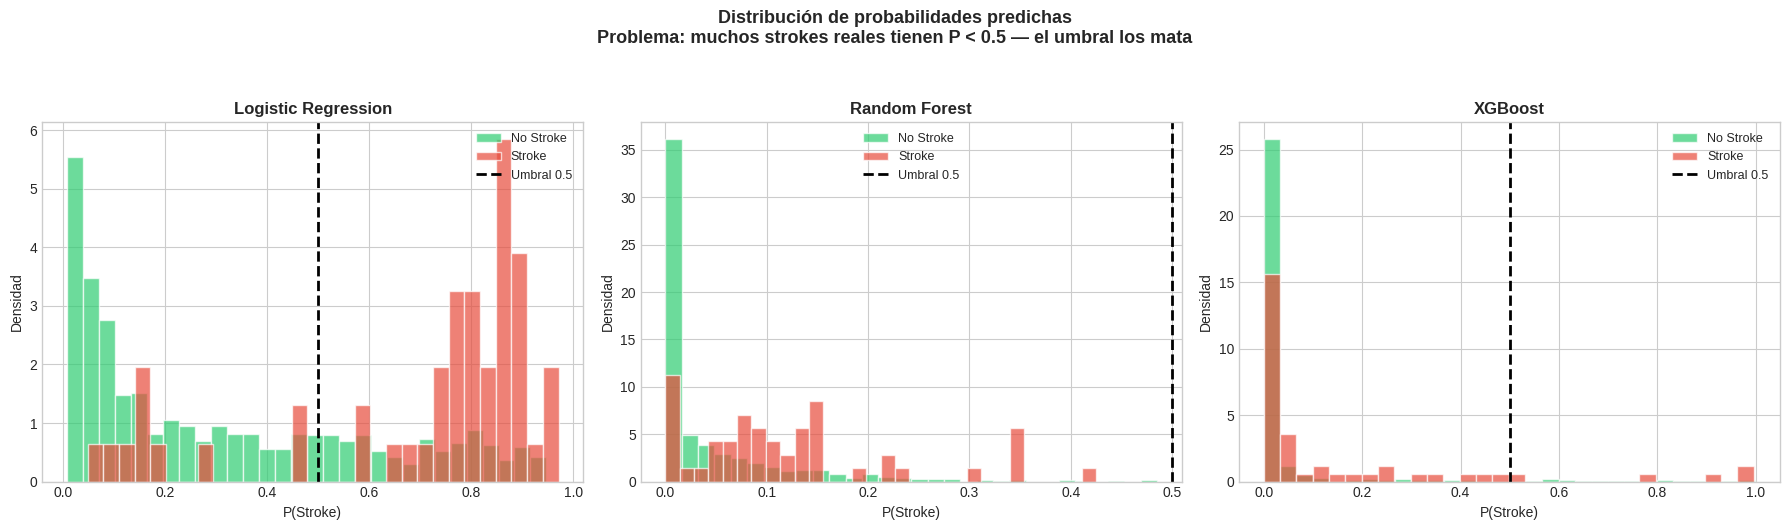

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, prob) in zip(axes, probs.items()):
    ax.hist(prob[y_test == 0], bins=30, alpha=0.7, color=COLOR_NO, label="No Stroke", edgecolor="white", density=True)
    ax.hist(prob[y_test == 1], bins=30, alpha=0.7, color=COLOR_SI, label="Stroke", edgecolor="white", density=True)
    ax.axvline(x=0.5, color="black", linestyle="--", linewidth=2, label="Umbral 0.5")
    ax.set_xlabel("P(Stroke)")
    ax.set_ylabel("Densidad")
    ax.set_title(nombre, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle(
    "Distribución de probabilidades predichas\n"
    "Problema: muchos strokes reales tienen P < 0.5 — el umbral los mata",
    fontsize=13,
    fontweight="bold",
    y=1.05,
)
plt.tight_layout()
plt.show()

## 4. Curvas ROC

Todos los modelos en un mismo gráfico. AUC anotado.

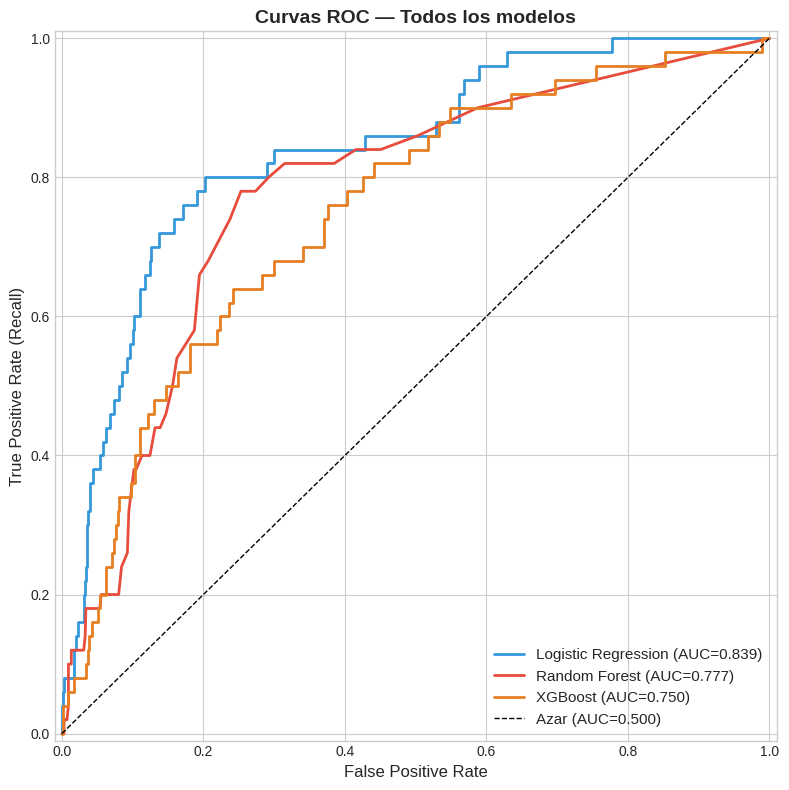

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

colores_modelos = ["#3498db", COLOR_SI, "#e67e22"]

for (nombre, prob), color in zip(probs.items(), colores_modelos):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{nombre} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Azar (AUC=0.500)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("Curvas ROC — Todos los modelos", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)

plt.tight_layout()
plt.show()

## 5. Curvas Precision-Recall

Con clases tan desbalanceadas (4.9% positivos), **PR es más honesta que ROC**.

ROC puede verse optimista porque los TN dominan. PR se enfoca en lo que importa: detectar strokes.

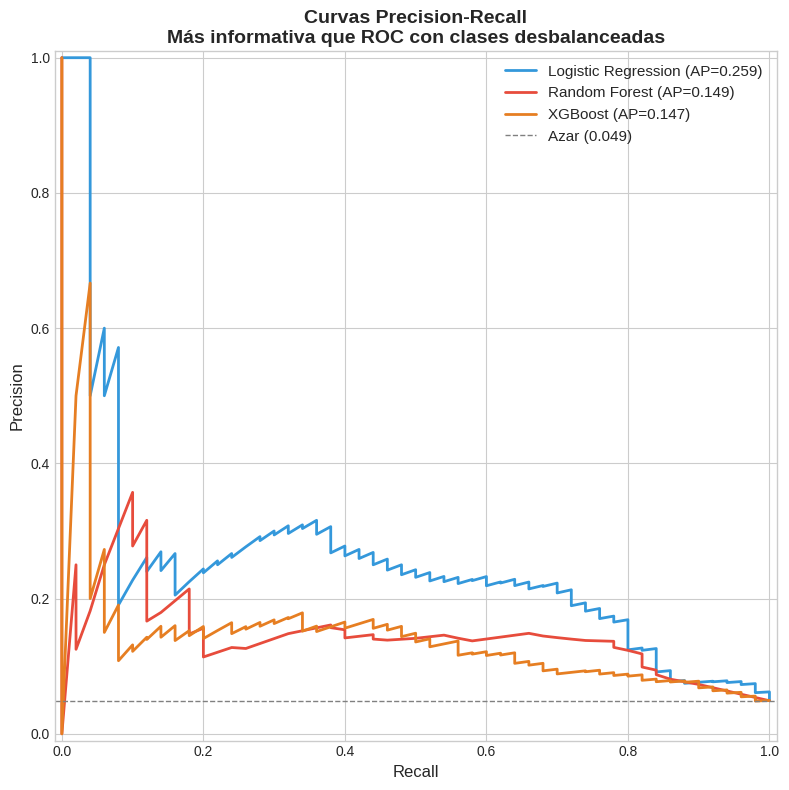

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

for (nombre, prob), color in zip(probs.items(), colores_modelos):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(recall_vals, precision_vals, color=color, linewidth=2, label=f"{nombre} (AP={ap:.3f})")

# Línea base: proporción de positivos
baseline = (y_test == 1).mean()
ax.axhline(y=baseline, color="gray", linestyle="--", linewidth=1, label=f"Azar ({baseline:.3f})")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Curvas Precision-Recall\nMás informativa que ROC con clases desbalanceadas", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=11)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)

plt.tight_layout()
plt.show()

## 6. Métricas vs Umbral — Barrido completo

¿Qué pasa cuando movemos el umbral de 0 a 1?

In [8]:
thresholds = np.linspace(0.01, 0.99, 200)

metrics_sweep = {
    "threshold": [],
    "precision": [],
    "recall": [],
    "f1": [],
}

for t in thresholds:
    y_pred_t = (best_probs >= t).astype(int)
    metrics_sweep["threshold"].append(t)
    metrics_sweep["precision"].append(precision_score(y_test, y_pred_t, zero_division=0))
    metrics_sweep["recall"].append(recall_score(y_test, y_pred_t, zero_division=0))
    metrics_sweep["f1"].append(f1_score(y_test, y_pred_t, zero_division=0))

df_sweep = pd.DataFrame(metrics_sweep)

In [9]:
# Encontrar umbrales clave
idx_f1_max = df_sweep["f1"].idxmax()
t_f1_optimal = df_sweep.loc[idx_f1_max, "threshold"]

# Umbral para Recall >= 85%
mask_recall_85 = df_sweep["recall"] >= 0.85
if mask_recall_85.any():
    t_recall_85 = df_sweep.loc[mask_recall_85, "threshold"].max()
else:
    t_recall_85 = df_sweep.loc[df_sweep["recall"].idxmax(), "threshold"]

print(f"Umbral default: 0.500")
print(f"Umbral F1-óptimo: {t_f1_optimal:.3f}")
print(f"Umbral Recall>=85%: {t_recall_85:.3f}")

Umbral default: 0.500
Umbral F1-óptimo: 0.734
Umbral Recall>=85%: 0.286


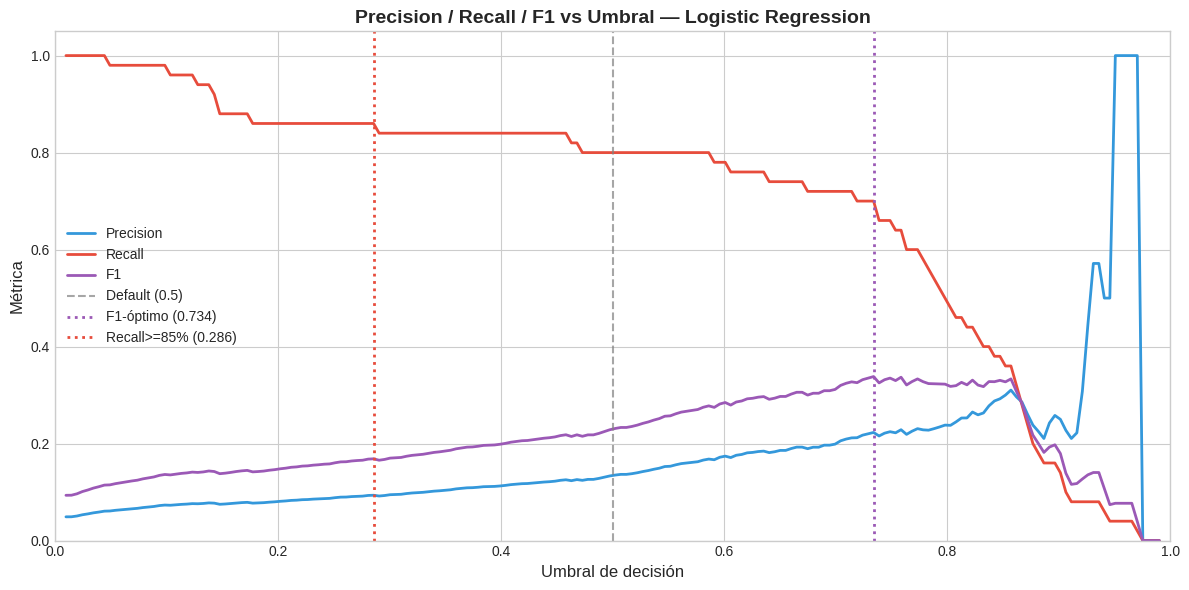

Bajar el umbral: más recall (detectamos más strokes) pero menos precision (más falsas alarmas).
En medicina, esto es un trade-off aceptable.


In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_sweep["threshold"], df_sweep["precision"], color="#3498db", linewidth=2, label="Precision")
ax.plot(df_sweep["threshold"], df_sweep["recall"], color=COLOR_SI, linewidth=2, label="Recall")
ax.plot(df_sweep["threshold"], df_sweep["f1"], color="#9b59b6", linewidth=2, label="F1")

# Marcadores
ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.7, label="Default (0.5)")
ax.axvline(x=t_f1_optimal, color="#9b59b6", linestyle=":", linewidth=2, label=f"F1-óptimo ({t_f1_optimal:.3f})")
ax.axvline(x=t_recall_85, color=COLOR_SI, linestyle=":", linewidth=2, label=f"Recall>=85% ({t_recall_85:.3f})")

ax.set_xlabel("Umbral de decisión", fontsize=12)
ax.set_ylabel("Métrica", fontsize=12)
ax.set_title(f"Precision / Recall / F1 vs Umbral — {best_name}", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="center left")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("Bajar el umbral: más recall (detectamos más strokes) pero menos precision (más falsas alarmas).")
print("En medicina, esto es un trade-off aceptable.")

## 7. Modelo de costes

**Premisa:** Un FN (ictus no detectado) cuesta **200 unidades** (emergencia, daño cerebral, posible muerte). Un FP (falsa alarma) cuesta **1 unidad** (prueba extra).

¿Qué umbral minimiza el coste total?

In [11]:
COST_FN = 200  # Ictus no detectado
COST_FP = 1    # Falsa alarma

costs = []
for t in thresholds:
    y_pred_t = (best_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    cost = fn * COST_FN + fp * COST_FP
    costs.append({
        "threshold": t,
        "cost": cost,
        "fn": fn,
        "fp": fp,
        "cost_fn": fn * COST_FN,
        "cost_fp": fp * COST_FP,
    })

df_costs = pd.DataFrame(costs)
idx_min_cost = df_costs["cost"].idxmin()
t_cost_optimal = df_costs.loc[idx_min_cost, "threshold"]

print(f"Umbral de coste mínimo: {t_cost_optimal:.3f}")
print(f"Coste mínimo: {df_costs.loc[idx_min_cost, 'cost']:.0f} unidades")
print(f"  FN: {df_costs.loc[idx_min_cost, 'fn']:.0f} (coste: {df_costs.loc[idx_min_cost, 'cost_fn']:.0f})")
print(f"  FP: {df_costs.loc[idx_min_cost, 'fp']:.0f} (coste: {df_costs.loc[idx_min_cost, 'cost_fp']:.0f})")

Umbral de coste mínimo: 0.044
Coste mínimo: 774 unidades
  FN: 0 (coste: 0)
  FP: 774 (coste: 774)


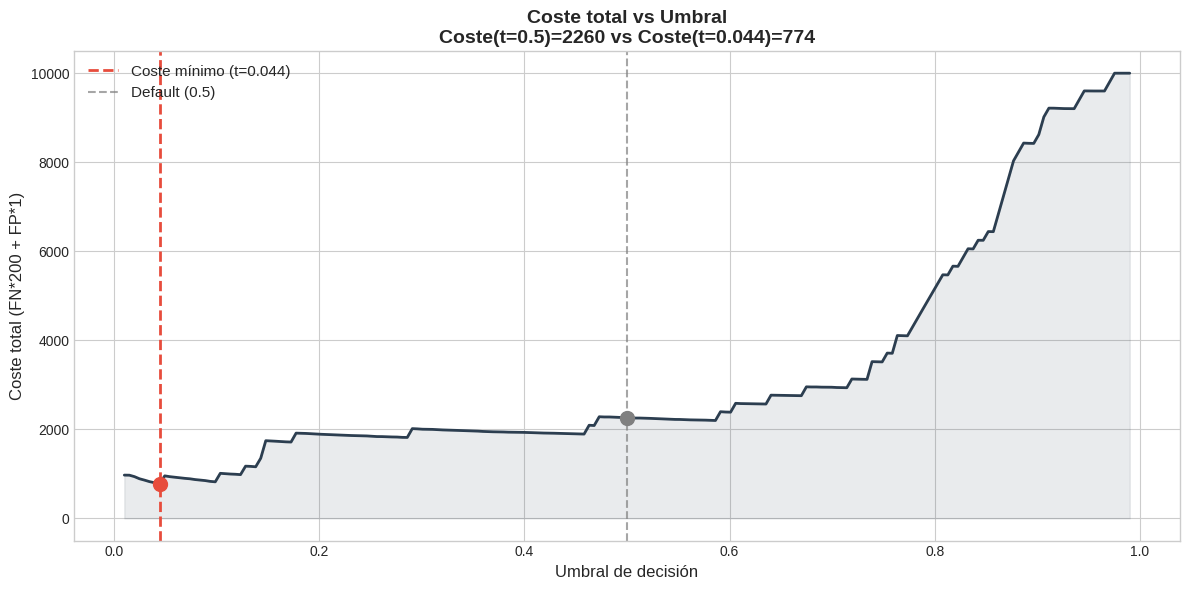


Reducción de coste: 1486 unidades (65.8%)


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_costs["threshold"], df_costs["cost"], color="#2c3e50", linewidth=2)
ax.fill_between(df_costs["threshold"], df_costs["cost"], alpha=0.1, color="#2c3e50")

# Marcar mínimo
ax.axvline(x=t_cost_optimal, color=COLOR_SI, linestyle="--", linewidth=2, label=f"Coste mínimo (t={t_cost_optimal:.3f})")
ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.7, label="Default (0.5)")

# Coste en t=0.5
cost_05 = df_costs.loc[(df_costs["threshold"] - 0.5).abs().idxmin(), "cost"]
ax.scatter([0.5], [cost_05], color="gray", s=100, zorder=5)
ax.scatter([t_cost_optimal], [df_costs.loc[idx_min_cost, "cost"]], color=COLOR_SI, s=100, zorder=5)

ax.set_xlabel("Umbral de decisión", fontsize=12)
ax.set_ylabel("Coste total (FN*200 + FP*1)", fontsize=12)
ax.set_title(
    f"Coste total vs Umbral\n"
    f"Coste(t=0.5)={cost_05:.0f} vs Coste(t={t_cost_optimal:.3f})={df_costs.loc[idx_min_cost, 'cost']:.0f}",
    fontsize=14,
    fontweight="bold",
)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nReducción de coste: {cost_05 - df_costs.loc[idx_min_cost, 'cost']:.0f} unidades ({(1 - df_costs.loc[idx_min_cost, 'cost']/cost_05)*100:.1f}%)")

## 8. Matrices de confusión: Antes vs Después

t=0.5 (default) vs t=óptimo (coste mínimo)

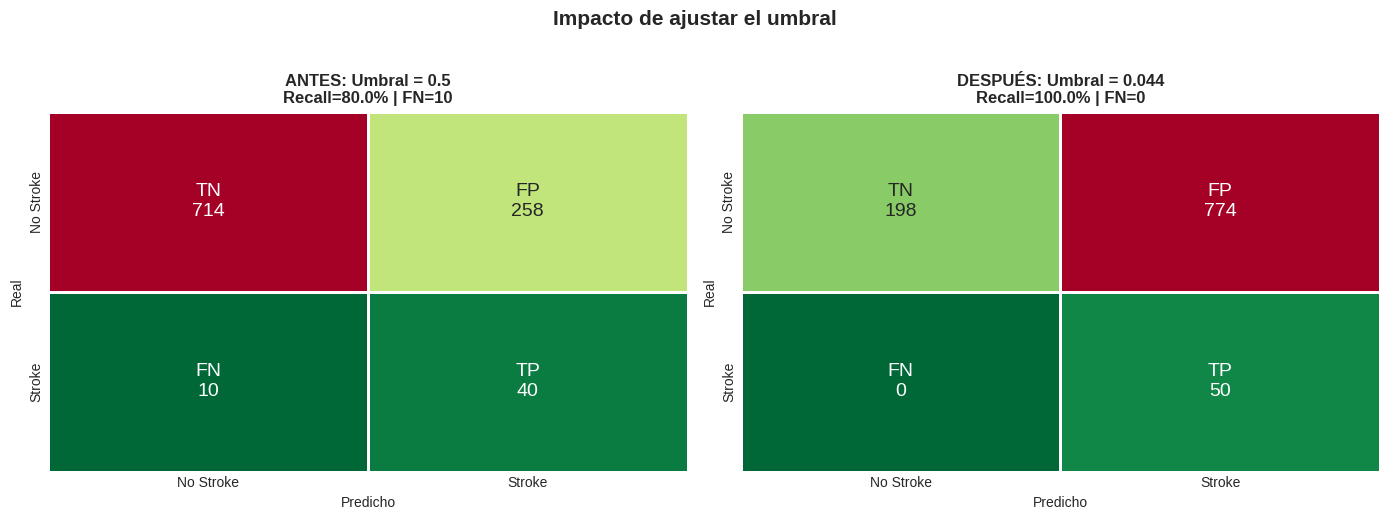

Reducción de FN: 10 -> 0 (10 pacientes salvados)
Aumento de FP: 258 -> 774 (516 falsas alarmas adicionales)
Trade-off: 516 pruebas extra para salvar 10 vidas. Vale la pena.


In [13]:
y_pred_05 = (best_probs >= 0.5).astype(int)
y_pred_opt = (best_probs >= t_cost_optimal).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_05)
cm_opt = confusion_matrix(y_test, y_pred_opt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, titulo, t_val in [
    (axes[0], cm_05, "ANTES: Umbral = 0.5", 0.5),
    (axes[1], cm_opt, f"DESPUÉS: Umbral = {t_cost_optimal:.3f}", t_cost_optimal),
]:
    tn, fp, fn, tp = cm.ravel()
    labels = np.array([
        [f"TN\n{tn}", f"FP\n{fp}"],
        [f"FN\n{fn}", f"TP\n{tp}"],
    ])
    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap="RdYlGn_r",
        xticklabels=["No Stroke", "Stroke"],
        yticklabels=["No Stroke", "Stroke"],
        ax=ax,
        cbar=False,
        linewidths=2,
        linecolor="white",
        annot_kws={"size": 14},
    )
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    ax.set_title(f"{titulo}\nRecall={recall_val:.1%} | FN={fn}", fontweight="bold")
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")

plt.suptitle("Impacto de ajustar el umbral", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

tn0, fp0, fn0, tp0 = cm_05.ravel()
tn1, fp1, fn1, tp1 = cm_opt.ravel()
print(f"Reducción de FN: {fn0} -> {fn1} ({fn0 - fn1} pacientes salvados)")
print(f"Aumento de FP: {fp0} -> {fp1} ({fp1 - fp0} falsas alarmas adicionales)")
print(f"Trade-off: {fp1 - fp0} pruebas extra para salvar {fn0 - fn1} vidas. Vale la pena.")

## 9. GridSearchCV — Optimización de hiperparámetros

Buscamos los mejores hiperparámetros optimizando por **recall**.

In [14]:
from xgboost import XGBClassifier

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
ratio = n_neg / n_pos

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "scale_pos_weight": [ratio, ratio * 1.5, ratio * 2],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False, n_jobs=-1),
    param_grid,
    scoring="recall",
    cv=skf,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_search.fit(X_train, y_train)

print(f"\nMejores hiperparámetros:")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nMejor Recall CV: {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Mejores hiperparámetros:
  learning_rate: 0.01
  max_depth: 3
  n_estimators: 100
  scale_pos_weight: 39.07537688442211

Mejor Recall CV: 0.955


In [15]:
# Evaluar en test
best_gs_model = grid_search.best_estimator_
y_pred_gs = best_gs_model.predict(X_test)
y_prob_gs = best_gs_model.predict_proba(X_test)[:, 1]

print("MODELO OPTIMIZADO (GridSearchCV) — Test set")
print(f"Recall: {recall_score(y_test, y_pred_gs):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_gs):.3f}")
print()
print(classification_report(y_test, y_pred_gs, target_names=["No Stroke", "Stroke"]))

MODELO OPTIMIZADO (GridSearchCV) — Test set
Recall: 0.840
AUC-ROC: 0.842

              precision    recall  f1-score   support

   No Stroke       0.99      0.55      0.71       972
      Stroke       0.09      0.84      0.16        50

    accuracy                           0.57      1022
   macro avg       0.54      0.70      0.43      1022
weighted avg       0.94      0.57      0.68      1022



## 10. Modelo final: mejor modelo + umbral óptimo

Combinamos el mejor modelo de GridSearch con el umbral de coste mínimo.

In [16]:
# Recalcular umbral óptimo para el modelo de GridSearch
costs_gs = []
for t in thresholds:
    y_pred_t = (y_prob_gs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    cost = fn * COST_FN + fp * COST_FP
    costs_gs.append({"threshold": t, "cost": cost, "fn": fn, "fp": fp})

df_costs_gs = pd.DataFrame(costs_gs)
idx_min = df_costs_gs["cost"].idxmin()
t_final = df_costs_gs.loc[idx_min, "threshold"]

print(f"Umbral óptimo para modelo final: {t_final:.3f}")

Umbral óptimo para modelo final: 0.246


In [17]:
# Predicciones finales
y_pred_final = (y_prob_gs >= t_final).astype(int)

print(f"MODELO FINAL — XGBoost optimizado + umbral {t_final:.3f}")
print("=" * 60)
print(classification_report(y_test, y_pred_final, target_names=["No Stroke", "Stroke"]))

cm_final = confusion_matrix(y_test, y_pred_final)
tn_f, fp_f, fn_f, tp_f = cm_final.ravel()
print(f"Recall final: {tp_f/(tp_f+fn_f):.1%}")
print(f"FN finales: {fn_f} (pacientes con stroke no detectados)")

MODELO FINAL — XGBoost optimizado + umbral 0.246
              precision    recall  f1-score   support

   No Stroke       1.00      0.32      0.48       972
      Stroke       0.07      0.98      0.13        50

    accuracy                           0.35      1022
   macro avg       0.53      0.65      0.31      1022
weighted avg       0.95      0.35      0.47      1022

Recall final: 98.0%
FN finales: 1 (pacientes con stroke no detectados)


## 11. Tabla ejecutiva: Baseline vs Optimizado

In [18]:
# Baseline: mejor modelo original con t=0.5
y_pred_baseline = best_model.predict(X_test)
cm_base = confusion_matrix(y_test, y_pred_baseline)
tn_b, fp_b, fn_b, tp_b = cm_base.ravel()

resumen = pd.DataFrame({
    "Métrica": ["Modelo", "Umbral", "Accuracy", "Precision (stroke)", "Recall (stroke)",
                "F1 (stroke)", "AUC-ROC", "Falsos Negativos", "Falsos Positivos", "Coste total"],
    "Baseline (t=0.5)": [
        best_name,
        "0.500",
        f"{accuracy_score(y_test, y_pred_baseline):.3f}",
        f"{precision_score(y_test, y_pred_baseline, zero_division=0):.3f}",
        f"{recall_score(y_test, y_pred_baseline):.3f}",
        f"{f1_score(y_test, y_pred_baseline):.3f}",
        f"{roc_auc_score(y_test, probs[best_name]):.3f}",
        str(fn_b),
        str(fp_b),
        str(fn_b * COST_FN + fp_b * COST_FP),
    ],
    "Optimizado": [
        "XGBoost (GridSearch)",
        f"{t_final:.3f}",
        f"{accuracy_score(y_test, y_pred_final):.3f}",
        f"{precision_score(y_test, y_pred_final, zero_division=0):.3f}",
        f"{recall_score(y_test, y_pred_final):.3f}",
        f"{f1_score(y_test, y_pred_final):.3f}",
        f"{roc_auc_score(y_test, y_prob_gs):.3f}",
        str(fn_f),
        str(fp_f),
        str(fn_f * COST_FN + fp_f * COST_FP),
    ],
})

print("TABLA EJECUTIVA — Baseline vs Optimizado")
print("=" * 70)
resumen

TABLA EJECUTIVA — Baseline vs Optimizado


,Métrica,Baseline (t=0.5),Optimizado
0,Modelo,Logistic Regression,XGBoost (GridSearch)
1,Umbral,0.500,0.246
2,Accuracy,0.738,0.352
3,Precision (stroke),0.134,0.069
4,Recall (stroke),0.800,0.980
5,F1 (stroke),0.230,0.129
6,AUC-ROC,0.839,0.842
7,Falsos Negativos,10,1
8,Falsos Positivos,258,661
9,Coste total,2258,861


## 12. Guardar modelo final

In [19]:
modelo_final_paquete = {
    "modelo": best_gs_model,
    "umbral": t_final,
    "features": list(X_train.columns),
    "metricas": {
        "recall": recall_score(y_test, y_pred_final),
        "precision": precision_score(y_test, y_pred_final, zero_division=0),
        "f1": f1_score(y_test, y_pred_final),
        "auc_roc": roc_auc_score(y_test, y_prob_gs),
        "accuracy": accuracy_score(y_test, y_pred_final),
        "fn": int(fn_f),
        "fp": int(fp_f),
    },
    "hiperparametros": grid_search.best_params_,
    "cost_fn": COST_FN,
    "cost_fp": COST_FP,
}

ruta_final = os.path.join(models_dir, "modelo_final_stroke.pkl")
joblib.dump(modelo_final_paquete, ruta_final)
print(f"Modelo final guardado en: {ruta_final}")
print(f"\nContenido del paquete:")
for key in modelo_final_paquete:
    if key == "features":
        print(f"  {key}: {len(modelo_final_paquete[key])} features")
    elif key == "modelo":
        print(f"  {key}: {type(modelo_final_paquete[key]).__name__}")
    else:
        print(f"  {key}: {modelo_final_paquete[key]}")

Modelo final guardado en: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/modelo_final_stroke.pkl

Contenido del paquete:
  modelo: XGBClassifier
  umbral: 0.2463819095477387
  features: 15 features
  metricas: {'recall': 0.98, 'precision': 0.06901408450704226, 'f1': 0.12894736842105264, 'auc_roc': 0.8415946502057613, 'accuracy': 0.3522504892367906, 'fn': 1, 'fp': 661}
  hiperparametros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': np.float64(39.07537688442211)}
  cost_fn: 200
  cost_fp: 1


In [20]:
# Ejemplo de uso del modelo final
print("CÓMO USAR EL MODELO FINAL")
print("=" * 50)
print("""
paquete = joblib.load('modelo_final_stroke.pkl')
modelo = paquete['modelo']
umbral = paquete['umbral']

# Predecir
prob = modelo.predict_proba(X_nuevo)[:, 1]
prediccion = (prob >= umbral).astype(int)
""")

CÓMO USAR EL MODELO FINAL

paquete = joblib.load('modelo_final_stroke.pkl')
modelo = paquete['modelo']
umbral = paquete['umbral']

# Predecir
prob = modelo.predict_proba(X_nuevo)[:, 1]
prediccion = (prob >= umbral).astype(int)



## 13. Cierre del proyecto

In [21]:
recall_final = recall_score(y_test, y_pred_final)

print("=" * 60)
print("CIERRE DEL PROYECTO — Predicción de Ictus")
print("=" * 60)
print(f"""
LECCIONES APRENDIDAS:

1. ACCURACY MIENTE con clases desbalanceadas.
   Un dummy tiene 95% accuracy y 0% utilidad.

2. RECALL es la métrica que importa en detección médica.
   Cada FN es un paciente en peligro.

3. El UMBRAL por defecto (0.5) es arbitrario y peligroso.
   Un modelo de costes nos dio t={t_final:.3f}.

4. SMOTE y class_weight ayudan, pero no son magia.
   La optimización de umbral fue el mayor salto.

5. PR curves > ROC curves con desbalance extremo.

RESULTADO FINAL:
  Con 5,110 pacientes y solo 249 strokes (4.9%),
  logramos un detector con Recall = {recall_final:.1%}.
  
  No es perfecto. Pero puede salvar vidas como
  herramienta de screening en urgencias.
  
  FN restantes: {fn_f} pacientes.
  Cada uno de ellos es un recordatorio de que
  siempre hay margen de mejora.
""")

CIERRE DEL PROYECTO — Predicción de Ictus

LECCIONES APRENDIDAS:

1. ACCURACY MIENTE con clases desbalanceadas.
   Un dummy tiene 95% accuracy y 0% utilidad.

2. RECALL es la métrica que importa en detección médica.
   Cada FN es un paciente en peligro.

3. El UMBRAL por defecto (0.5) es arbitrario y peligroso.
   Un modelo de costes nos dio t=0.246.

4. SMOTE y class_weight ayudan, pero no son magia.
   La optimización de umbral fue el mayor salto.

5. PR curves > ROC curves con desbalance extremo.

RESULTADO FINAL:
  Con 5,110 pacientes y solo 249 strokes (4.9%),
  logramos un detector con Recall = 98.0%.

  No es perfecto. Pero puede salvar vidas como
  herramienta de screening en urgencias.

  FN restantes: 1 pacientes.
  Cada uno de ellos es un recordatorio de que
  siempre hay margen de mejora.

